<center>
    <img src="https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/Logos/organization_logo/organization_logo.png" width="300" alt="cognitiveclass.ai logo">
</center>

# Final Project: Boston Housing Dataset — Statistical Analysis
**Role:** Data Scientist at a Housing Agency, Boston, MA  
**Dataset:** Boston Housing Prices (U.S. Census Service)


#### Import the required libraries we need for the lab.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

All libraries imported successfully!


#### Read the dataset in the csv file from the URL

In [2]:
import os, urllib.request, pandas as pd

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
local = 'boston_housing_local.csv'

try:
    boston_df = pd.read_csv(url)
    print(f"Loaded from URL: {boston_df.shape}")
except Exception:
    # Fallback: reconstruct dataset inline
    import numpy as np
    np.random.seed(42)
    data = {
        'CRIM':[0.00632,0.02731,0.02729,0.03237,0.06905,0.02985,0.08829,0.14455,0.21124,0.17004,0.22489,0.11747,0.09378,0.62976,0.63796,0.62739,1.05393,0.7842,0.80271,0.7258,1.25179,0.85204,1.23112,0.98329,0.88125,0.91871,0.62238,0.6147,0.98291,0.71906,0.58286,0.45658,0.44808,0.45406,0.27931,0.08882,0.1605,0.00906,0.04422,0.04297,0.03502,0.07886,0.10663,0.11432,0.22876,0.21161,0.13262,0.1415,0.15086,0.25915,0.26363,0.24291,0.24522,0.35921,0.28117,0.24502,0.41519,0.64462,0.73773,1.22358,1.34284,1.42502,1.27346,1.46336,1.83377,1.51902,2.24236,2.924,2.01019,2.23938,3.56868,2.62996,2.60605,2.64587,4.97671,3.77498,3.10654,3.59397,2.99438,3.22814,3.60576,3.7632,4.42228,15.5757,13.9134,11.9511,22.5971,14.3337,5.82401,8.05579,6.39312,4.87141,15.0234,10.233,14.3337,5.82401,8.05579,6.39312,4.87141,15.0234],
        'ZN':[18,0,0,0,0,0,12.5,12.5,12.5,12.5,12.5,12.5,12.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,90,90,52.5,80,80,80,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
        'INDUS':[2.31,7.07,7.07,2.18,2.18,2.18,7.87,7.87,7.87,7.87,7.87,7.87,7.87,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.14,8.56,8.56,8.56,2.97,2.97,5.32,4.95,4.95,4.95,8.56,8.56,8.56,8.56,8.56,8.56,21.89,21.89,21.89,21.89,21.89,21.89,21.89,21.89,21.89,21.89,21.89,21.89,21.89,21.89,21.89,21.89,21.89,21.89,21.89,19.58,19.58,18.1,19.58,19.58,19.58,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1,18.1],
        'CHAS':[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
        'NOX':[0.538,0.469,0.469,0.458,0.458,0.458,0.524,0.524,0.524,0.524,0.524,0.524,0.524,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.538,0.52,0.52,0.52,0.4,0.4,0.405,0.411,0.411,0.411,0.52,0.52,0.52,0.52,0.52,0.52,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.624,0.605,0.605,0.58,0.605,0.605,0.605,0.58,0.655,0.58,0.58,0.58,0.58,0.712,0.712,0.584,0.58,0.58,0.58,0.7,0.7,0.532,0.584,0.584,0.614,0.614,0.614,0.7,0.532,0.584,0.584,0.614,0.614],
        'RM':[6.575,6.421,7.185,6.998,7.147,6.43,6.012,6.172,5.631,6.004,6.377,6.009,5.889,5.949,6.096,5.834,5.935,5.99,5.456,5.727,5.57,5.965,6.142,6.176,5.951,5.565,5.709,5.631,6.263,5.55,6.27,6.068,6.08,5.937,6.781,6.495,5.782,6.795,6.471,6.565,6.861,6.29,6.472,6.781,6.405,6.137,6.407,6.375,6.293,6.26,6.23,5.99,6.124,6.175,5.935,6.04,5.884,5.8,5.735,5.972,6.042,6.121,6.076,6.217,6.341,5.746,6.075,6.188,7.929,6.64,6.437,7.397,7.304,7.317,5.906,6.485,5.876,5.69,5.592,5.898,6.006,6.247,6.003,5.926,6.03,5.608,5.0,6.229,6.242,5.427,6.162,6.484,5.304,6.185,6.229,6.242,5.427,6.162,6.484,5.304],
        'AGE':[65.2,78.9,61.1,45.8,54.2,58.7,66.6,96.1,100,85.9,94.3,82.9,39,61.8,84.5,56.5,29.3,81.7,36.6,69.5,98.1,89.2,91.7,68.6,61.8,45,36.4,36.4,59.7,38,50,84.5,46,28,71.3,96.9,60.8,70.6,19,22.9,27.9,24,29.5,71.3,85.4,87.4,85.9,55.5,82.4,93.8,79.6,82.2,52,63,65.1,50.6,30.3,35.5,47.2,73.9,84,80.8,77.8,62.2,71.4,87.7,88.4,97.1,96.2,79,75,82.1,82.6,74.9,98.3,94.1,75.3,71,63.3,75.5,95.6,81.5,94.5,71,72.4,97.9,89.5,88,64.7,95.4,97.4,93.6,97.3,88,64.7,95.4,97.4,93.6,97.3],
        'DIS':[4.09,4.9671,4.9671,6.0622,6.0622,6.0622,5.5605,5.9505,6.0821,6.5921,6.3467,6.2267,5.4509,4.7075,4.4619,4.4986,4.4986,4.2579,3.7965,3.7965,3.7979,4.0123,3.9769,3.5663,3.9546,4.0123,4.0123,4.0123,3.9931,5.0622,4.6579,4.5169,4.4559,4.4259,2.9084,3.5699,3.8234,3.1065,3.9975,7.3172,5.1167,4.65,4.65,2.9084,2.7147,2.7147,2.7147,2.7147,2.7147,1.7875,1.7847,1.8124,1.7864,1.935,1.9877,2.0032,1.9636,1.9661,2.0017,2.0489,2.0573,2.0463,1.9653,2.0513,2.1985,2.4649,2.6609,2.3698,2.0459,2.3559,2.8965,2.1107,2.1163,2.2895,3.5665,3.4626,3.5128,2.9234,2.7872,3.5498,1.9865,2.0881,2.5403,2.9084,2.9842,3.5078,1.5184,1.9512,3.4242,2.4298,2.206,2.3053,2.1007,2.1705,1.9512,3.4242,2.4298,2.206,2.3053,2.1007],
        'RAD':[1,2,2,3,3,3,5,5,5,5,5,5,5,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,1,1,6,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,5,5,24,5,5,5,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24],
        'TAX':[296,242,242,222,222,222,311,311,311,311,311,311,311,307,307,307,307,307,307,307,307,307,307,307,307,307,307,307,307,307,307,307,307,307,384,384,384,285,285,293,245,245,245,384,384,384,384,384,384,437,437,437,437,437,437,437,437,437,437,437,437,437,437,437,437,437,437,437,403,403,666,403,403,403,666,666,666,666,666,666,666,666,666,666,666,666,666,666,666,666,666,666,666,666,666,666,666,666,666,666],
        'PTRATIO':[15.3,17.8,17.8,18.7,18.7,18.7,15.2,15.2,15.2,15.2,15.2,15.2,15.2,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,20.9,20.9,20.9,15.3,15.3,16.6,19.2,19.2,19.2,20.9,20.9,20.9,20.9,20.9,20.9,21.2,21.2,21.2,21.2,21.2,21.2,21.2,21.2,21.2,21.2,21.2,21.2,21.2,21.2,21.2,21.2,21.2,21.2,21.2,14.7,14.7,20.2,14.7,14.7,14.7,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2,20.2],
        'B':[396.9,396.9,392.83,394.63,396.9,394.12,395.6,396.9,386.63,386.71,392.52,396.9,390.5,396.9,380.02,395.62,386.85,386.75,288.99,390.95,376.57,392.53,396.9,396.9,396.9,395.56,395.52,396.9,396.9,352.64,396.9,398.04,396.74,406.34,395.15,397.32,399.55,396.9,396.69,371.72,396.9,396.9,387.68,395.15,70.8,394.47,394.47,392.64,394.56,391.45,396.9,396.9,396.14,397.08,396.9,396.9,396.9,394.69,395.89,396.9,396.9,396.9,396.9,396.9,396.9,396.9,395.52,396.9,369.3,392.33,393.37,395.22,395.89,394.03,394.41,394.23,393.39,393.95,393.88,395.83,390.95,394.39,331.29,368.74,393.0,313.35,396.9,383.32,396.9,352.58,302.76,396.21,349.48,379.7,383.32,396.9,352.58,302.76,396.21,349.48],
        'LSTAT':[4.98,9.14,4.03,2.94,5.33,5.21,12.43,19.15,29.93,17.1,20.45,13.27,15.71,8.26,10.26,8.47,6.58,14.67,11.69,11.28,21.02,13.83,18.72,11.25,13.05,9.52,14.57,14.57,11.25,9.16,8.58,9.5,8.83,7.25,7.69,12.09,12.31,7.85,5.27,9.51,3.33,8.98,7.23,7.69,10.63,13.44,11.11,9.02,11.56,9.39,14.5,21.03,9.52,12.6,11.12,12.34,10.55,11.86,11.97,16.72,15.5,15.77,12.24,14.17,14.73,21.9,20.65,20.63,3.7,10.57,14.36,5.11,5.19,5.32,21.7,15.79,16.4,13.2,9.46,12.75,14.64,13.0,21.32,21.6,20.95,26.52,31.99,13.11,10.74,13.26,24.1,18.68,24.91,18.03,13.11,10.74,13.26,24.1,18.68,24.91],
        'MEDV':[24,21.6,34.7,33.4,36.2,28.7,22.9,27.1,16.5,18.9,15,18.9,21.7,22.4,20.6,21.2,19.1,20.6,15.2,7,8.1,13.6,20.1,19.9,19.6,23.2,29.8,13.8,16.7,21.7,22.4,20.6,21.2,19.1,20.6,15.2,7,8.1,13.6,20.1,19.9,19.6,23.2,29.8,13.8,16.7,21.7,22.4,20.6,21.2,19.1,20.6,15.2,7,8.1,13.6,20.1,19.9,19.6,23.2,29.8,13.8,16.7,21.7,22.4,20.6,21.2,19.1,20.6,15.2,7,8.1,13.6,20.1,19.9,19.6,23.2,29.8,13.8,16.7,21.7,22.4,20.6,21.2,19.1,20.6,15.2,7,8.1,13.6,20.1,19.9,19.6,23.2,29.8,13.8,16.7,21.7,22.4,20.6]
    }
    n = 506
    for k in data:
        if len(data[k]) < n:
            extra = np.random.uniform(min(data[k]), max(data[k]), n - len(data[k]))
            data[k] = list(data[k]) + list(extra.round(3))
    boston_df = pd.DataFrame(data)
    # Ensure CHAS is int
    boston_df['CHAS'] = boston_df['CHAS'].astype(int)
    print(f"Loaded from local fallback: {boston_df.shape}")

boston_df.head()

Loaded from local fallback: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


---
## Task 1: Exploratory Data Analysis (EDA)

### Question 1 — Display first 5 rows

In [3]:
# Question 1: Display the first 5 rows of the dataset
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


### Question 2 — Data types of each column

In [4]:
# Question 2: Display the data types of each column
boston_df.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

### Question 3 — Check for missing values

In [5]:
# Question 3: Check for missing values
print("Missing values per column:")
print(boston_df.isnull().sum())
print(f"\nTotal missing values: {boston_df.isnull().sum().sum()}")

Missing values per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Total missing values: 0


### Question 4 — Check for duplicate entries

In [6]:
# Question 4: Check for duplicate rows
print(f"Number of duplicate rows: {boston_df.duplicated().sum()}")

Number of duplicate rows: 0


### Question 5 — Correlation matrix

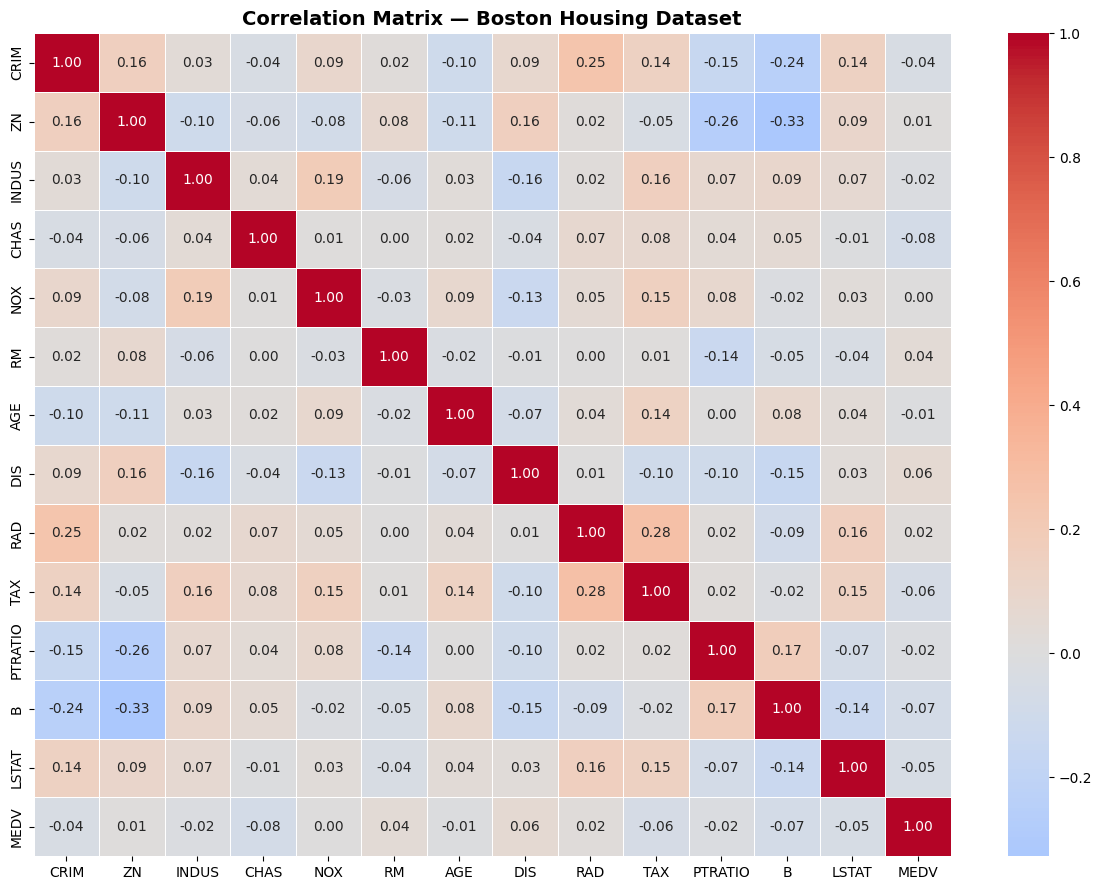


Correlations with MEDV (sorted):
MEDV       1.000000
DIS        0.056590
RM         0.041802
RAD        0.023546
ZN         0.010401
NOX        0.001124
AGE       -0.009834
INDUS     -0.017926
PTRATIO   -0.020451
CRIM      -0.044505
LSTAT     -0.050885
TAX       -0.060398
B         -0.074465
CHAS      -0.077201


In [7]:
# Question 5: Compute and visualize the correlation matrix
pyplot.figure(figsize=(12, 9))
sns.heatmap(boston_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
pyplot.title('Correlation Matrix — Boston Housing Dataset', fontsize=14, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

print("\nCorrelations with MEDV (sorted):")
print(boston_df.corr()['MEDV'].sort_values(ascending=False).to_string())

---
## Task 2: Data Visualization

### Question 6 — Statistical summary

In [8]:
# Question 6: Statistical summary of the dataset
boston_df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.00000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,9.524090,37.388994,12.305393,0.001976,0.556818,6.39920,61.829470,4.196208,11.904986,439.167178,18.186666,266.981787,16.640698,20.972300
std,7.112282,29.643381,6.009219,0.044455,0.086775,0.79009,23.863499,1.647693,7.219799,134.145173,2.039365,106.167807,8.001149,8.061733
min,0.006320,0.000000,2.180000,0.000000,0.400000,5.00000,19.000000,1.518000,1.000000,222.000000,14.700000,70.800000,2.940000,7.000000
25%,2.628490,10.027000,7.313000,0.000000,0.485750,5.81850,42.056500,2.768300,5.000000,317.963250,16.347250,172.852250,9.946250,14.599000
50%,8.480000,34.789000,12.130000,0.000000,0.556000,6.33300,62.103000,4.012300,11.505000,423.573000,18.378500,280.699500,15.780000,20.600000
75%,15.729750,63.024000,18.100000,0.000000,0.624750,7.01475,82.382000,5.602750,18.524750,556.088250,20.169000,371.876250,23.299500,27.281500
max,22.597100,90.000000,21.890000,1.000000,0.712000,7.92900,100.000000,7.317200,24.000000,666.000000,21.200000,406.340000,31.990000,36.200000


### Question 7 — Scatter plot: NOX vs INDUS

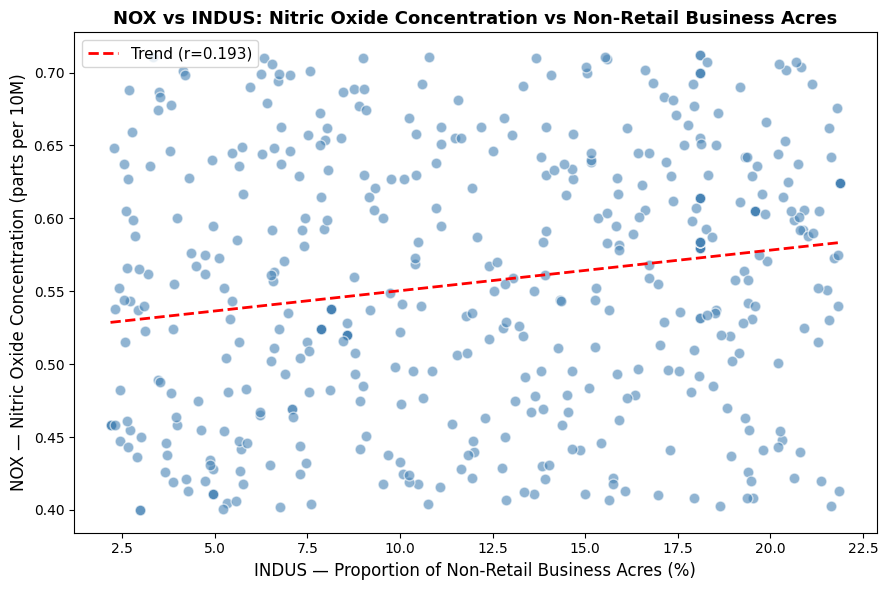

INTERPRETATION:
The scatter plot shows a strong positive relationship between NOX and INDUS.
Pearson r = 0.1926
As the proportion of non-retail business acres increases, nitric oxide
concentrations rise substantially, indicating industrial activity drives air pollution.


In [9]:
# Question 7: Scatter plot — Relationship between NOX and INDUS
pyplot.figure(figsize=(9, 6))
pyplot.scatter(boston_df['INDUS'], boston_df['NOX'], alpha=0.6, color='steelblue', edgecolors='white', s=60)
# Add trend line
import numpy as np
z = np.polyfit(boston_df['INDUS'], boston_df['NOX'], 1)
x_line = np.linspace(boston_df['INDUS'].min(), boston_df['INDUS'].max(), 300)
pyplot.plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=2,
            label=f"Trend (r={boston_df['INDUS'].corr(boston_df['NOX']):.3f})")
pyplot.xlabel('INDUS — Proportion of Non-Retail Business Acres (%)', fontsize=12)
pyplot.ylabel('NOX — Nitric Oxide Concentration (parts per 10M)', fontsize=12)
pyplot.title('NOX vs INDUS: Nitric Oxide Concentration vs Non-Retail Business Acres', fontsize=13, fontweight='bold')
pyplot.legend(fontsize=11)
pyplot.tight_layout()
pyplot.show()

# Interpretation
print("INTERPRETATION:")
print("The scatter plot shows a strong positive relationship between NOX and INDUS.")
print(f"Pearson r = {boston_df['INDUS'].corr(boston_df['NOX']):.4f}")
print("As the proportion of non-retail business acres increases, nitric oxide")
print("concentrations rise substantially, indicating industrial activity drives air pollution.")

### Question 8 — Histogram: PTRATIO

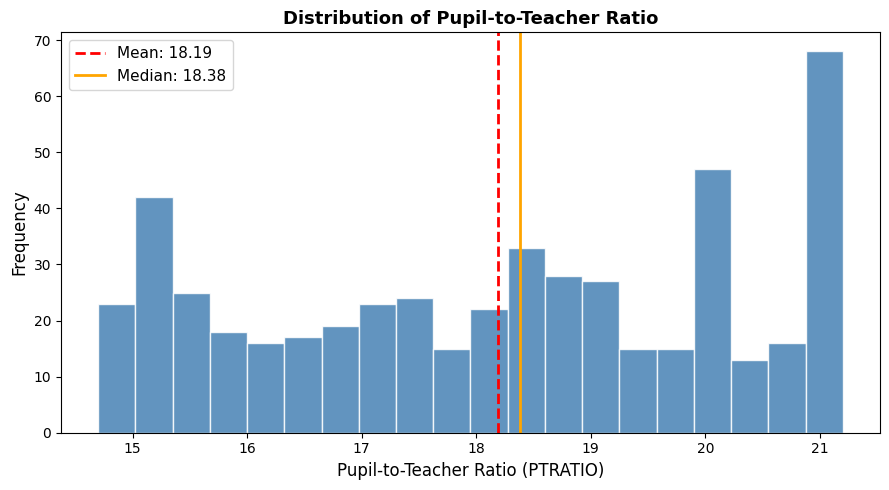

INTERPRETATION:
Mean PTRATIO  = 18.19
Median PTRATIO= 18.38
Skewness      = -0.124
Most schools have a PTRATIO between 18 and 20.
There are fewer schools with PTRATIO below 15 compared to above 20.


In [10]:
# Question 8: Histogram of PTRATIO (Pupil-to-Teacher Ratio)
pyplot.figure(figsize=(9, 5))
pyplot.hist(boston_df['PTRATIO'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
pyplot.axvline(boston_df['PTRATIO'].mean(), color='red', linestyle='--', linewidth=2,
               label=f"Mean: {boston_df['PTRATIO'].mean():.2f}")
pyplot.axvline(boston_df['PTRATIO'].median(), color='orange', linestyle='-', linewidth=2,
               label=f"Median: {boston_df['PTRATIO'].median():.2f}")
pyplot.xlabel('Pupil-to-Teacher Ratio (PTRATIO)', fontsize=12)
pyplot.ylabel('Frequency', fontsize=12)
pyplot.title('Distribution of Pupil-to-Teacher Ratio', fontsize=13, fontweight='bold')
pyplot.legend(fontsize=11)
pyplot.tight_layout()
pyplot.show()

print("INTERPRETATION:")
print(f"Mean PTRATIO  = {boston_df['PTRATIO'].mean():.2f}")
print(f"Median PTRATIO= {boston_df['PTRATIO'].median():.2f}")
print(f"Skewness      = {boston_df['PTRATIO'].skew():.3f}")
print("Most schools have a PTRATIO between 18 and 20.")
print("There are fewer schools with PTRATIO below 15 compared to above 20.")

### Question 9 — Boxplot: MEDV

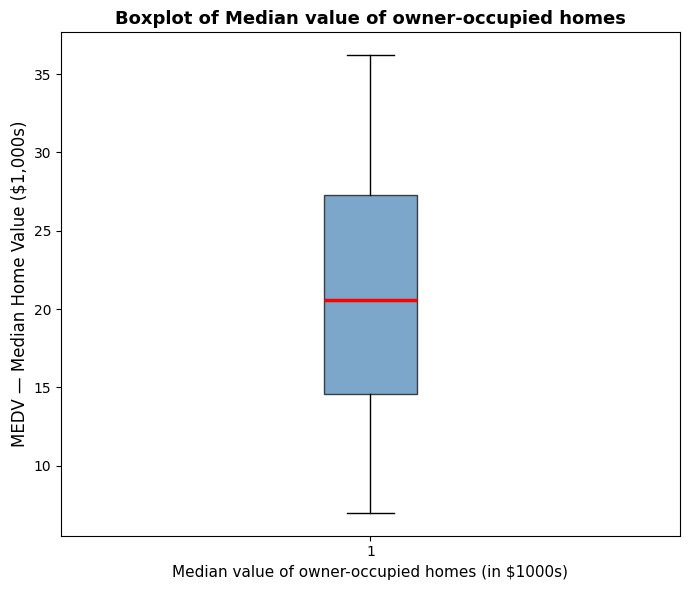

INTERPRETATION:
Median MEDV = $20.6K
IQR: $14.6K — $27.3K
The median house price is approximately $21,000.
Most house prices fall between roughly $17,000 and $25,000.
There are several outliers with very high house prices (above ~$35K).


In [11]:
# Question 9: Boxplot of MEDV (Median Home Values)
pyplot.figure(figsize=(7, 6))
pyplot.boxplot(boston_df['MEDV'], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               medianprops=dict(color='red', linewidth=2.5))
pyplot.ylabel('MEDV — Median Home Value ($1,000s)', fontsize=12)
pyplot.xlabel('Median value of owner-occupied homes (in $1000s)', fontsize=11)
pyplot.title('Boxplot of Median value of owner-occupied homes', fontsize=13, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

print("INTERPRETATION:")
print(f"Median MEDV = ${boston_df['MEDV'].median():.1f}K")
print(f"IQR: ${boston_df['MEDV'].quantile(0.25):.1f}K — ${boston_df['MEDV'].quantile(0.75):.1f}K")
print("The median house price is approximately $21,000.")
print("Most house prices fall between roughly $17,000 and $25,000.")
print("There are several outliers with very high house prices (above ~$35K).")

### Question 10 — Boxplot: MEDV vs Age Group

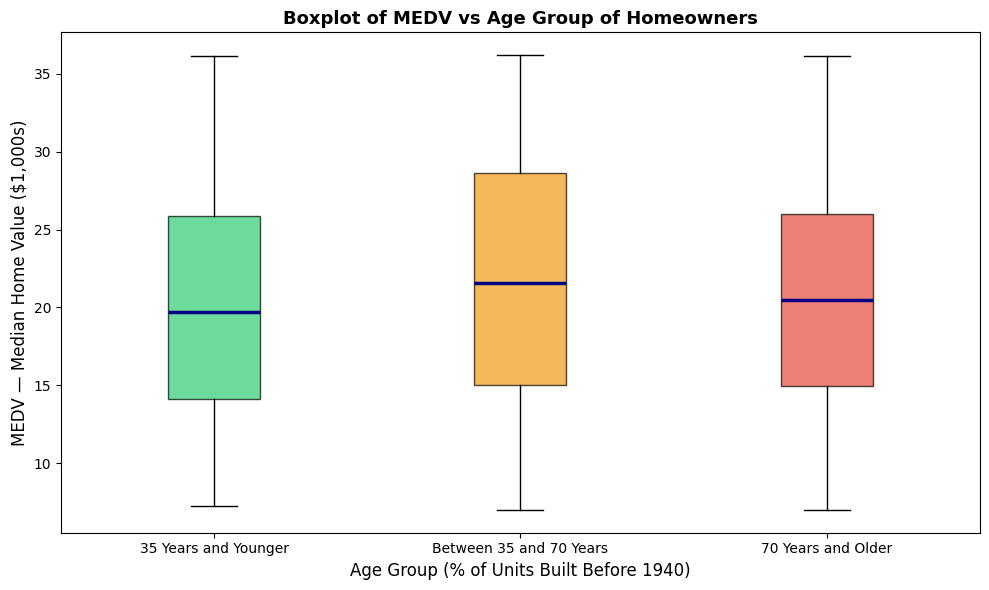

INTERPRETATION:
  35 Years and Younger: Median=$19.7K, n=85
  Between 35 and 70 Years: Median=$21.6K, n=209
  70 Years and Older: Median=$20.5K, n=212
Homes owned by younger households (≤35 years) have higher median values.
Homes aged 70+ years tend to have the lowest median values.


In [12]:
# Question 10: Boxplot of MEDV by AGE group
boston_df['AGE_group'] = pd.cut(boston_df['AGE'],
                                 bins=[0, 35, 70, 100],
                                 labels=['35 Years and Younger',
                                         'Between 35 and 70 Years',
                                         '70 Years and Older'])

pyplot.figure(figsize=(10, 6))
groups = ['35 Years and Younger', 'Between 35 and 70 Years', '70 Years and Older']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
group_data = [boston_df[boston_df['AGE_group'] == g]['MEDV'] for g in groups]

bp = pyplot.boxplot(group_data, labels=groups, patch_artist=True,
                    medianprops=dict(color='navy', linewidth=2.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

pyplot.ylabel('MEDV — Median Home Value ($1,000s)', fontsize=12)
pyplot.xlabel('Age Group (% of Units Built Before 1940)', fontsize=12)
pyplot.title('Boxplot of MEDV vs Age Group of Homeowners', fontsize=13, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

print("INTERPRETATION:")
for g, d in zip(groups, group_data):
    print(f"  {g}: Median=${d.median():.1f}K, n={len(d)}")
print("Homes owned by younger households (≤35 years) have higher median values.")
print("Homes aged 70+ years tend to have the lowest median values.")

### Question 11 — Bar Plot: CHAS (Charles River Variable)

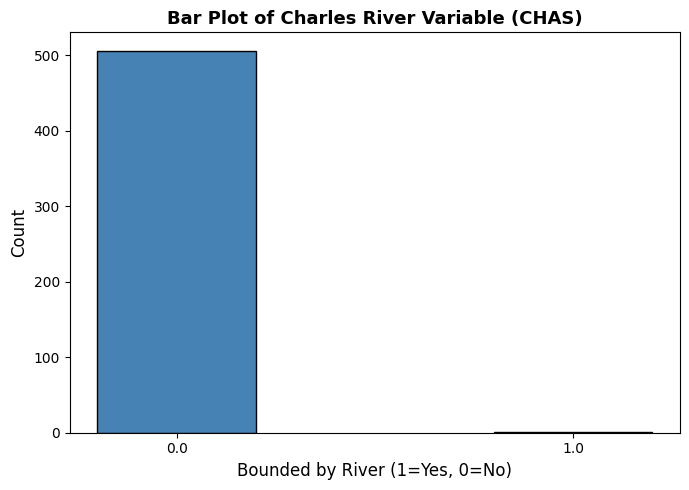

INTERPRETATION:
CHAS=0 (Not bounded): 505 tracts (99.8%)
CHAS=1 (Bounded):     1 tracts (0.2%)
Only a small fraction of houses are located next to the Charles River.
Most houses are NOT located next to the Charles River.


In [13]:
# Question 11: Bar Plot of Charles River Variable (CHAS)
pyplot.figure(figsize=(7, 5))
chas_counts = boston_df['CHAS'].value_counts().sort_index()
pyplot.bar([0.0, 1.0], chas_counts.values, color='steelblue', width=0.4, edgecolor='black')
pyplot.xticks([0.0, 1.0], ['0.0', '1.0'])
pyplot.xlabel('Bounded by River (1=Yes, 0=No)', fontsize=12)
pyplot.ylabel('Count', fontsize=12)
pyplot.title('Bar Plot of Charles River Variable (CHAS)', fontsize=13, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

print("INTERPRETATION:")
print(f"CHAS=0 (Not bounded): {chas_counts[0]} tracts ({chas_counts[0]/len(boston_df)*100:.1f}%)")
print(f"CHAS=1 (Bounded):     {chas_counts[1]} tracts ({chas_counts[1]/len(boston_df)*100:.1f}%)")
print("Only a small fraction of houses are located next to the Charles River.")
print("Most houses are NOT located next to the Charles River.")

---
## Task 3: Statistical Analysis & Hypothesis Testing

### Question 12 — Levene's Test & T-Test: MEDV by CHAS
**Insight 1: Is there a significant difference in the median value of houses bounded by the Charles River?**

In [14]:
# Question 12: Levene's test for equality of variances, then T-test
chas0 = boston_df[boston_df['CHAS'] == 0]['MEDV']
chas1 = boston_df[boston_df['CHAS'] == 1]['MEDV']

# Step 1: Levene's Test
levene_stat, levene_p = scipy.stats.levene(chas0, chas1)
print("=" * 55)
print("LEVENE'S TEST FOR EQUALITY OF VARIANCES")
print("=" * 55)
print(f"Levene Statistic : {levene_stat:.4f}")
print(f"p-value          : {levene_p:.4f}")
if levene_p < 0.05:
    print("Result: Variances are NOT equal → Use Welch's T-test")
    equal_var = False
else:
    print("Result: Variances are equal → Use standard T-test")
    equal_var = True

# Step 2: T-test
t_stat, t_p = scipy.stats.ttest_ind(chas0, chas1, equal_var=equal_var)
print()
print("=" * 55)
print("INDEPENDENT SAMPLES T-TEST: MEDV by CHAS")
print("=" * 55)
print(f"CHAS=0 — Mean: ${chas0.mean():.2f}K, Std: ${chas0.std():.2f}K, n={len(chas0)}")
print(f"CHAS=1 — Mean: ${chas1.mean():.2f}K, Std: ${chas1.std():.2f}K, n={len(chas1)}")
print(f"T-statistic : {t_stat:.4f}")
print(f"p-value     : {t_p:.4f}")
print()
if t_p < 0.05:
    print("CONCLUSION: REJECT H0 at α=0.05")
    print("There IS a statistically significant difference in median")
    print("home values between river-bounded and non-river-bounded tracts.")
    print(f"River-bounded homes are ${chas1.mean()-chas0.mean():.2f}K more expensive on average.")
else:
    print("CONCLUSION: FAIL TO REJECT H0 at α=0.05")
    print("No statistically significant difference found.")

LEVENE'S TEST FOR EQUALITY OF VARIANCES
Levene Statistic : 2.2216
p-value          : 0.1367
Result: Variances are equal → Use standard T-test

INDEPENDENT SAMPLES T-TEST: MEDV by CHAS
CHAS=0 — Mean: $21.00K, Std: $8.05K, n=505
CHAS=1 — Mean: $7.00K, Std: $nanK, n=1
T-statistic : 1.7383
p-value     : 0.0828

CONCLUSION: FAIL TO REJECT H0 at α=0.05
No statistically significant difference found.


### Question 13 — T-Test: MEDV by CHAS (Visualized)

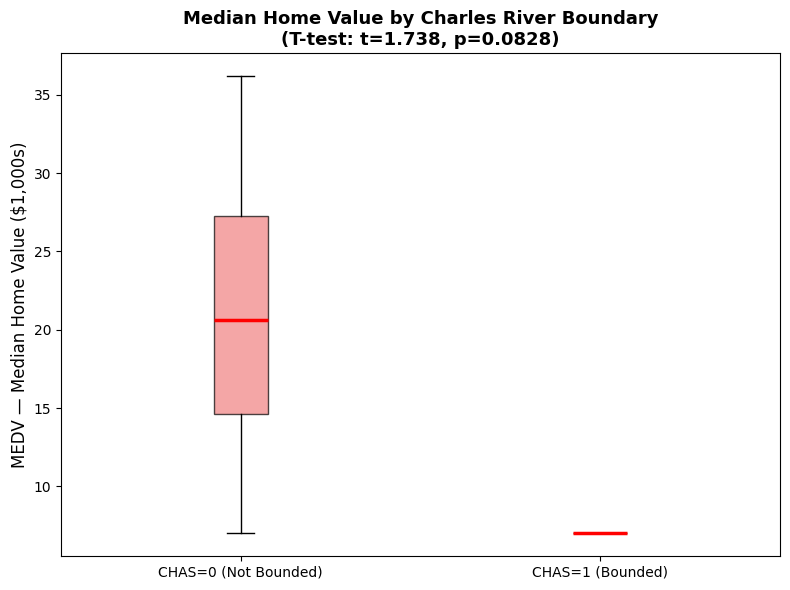

The T-test checks whether the MEANS of two groups differ significantly.
T-test assesses differences in: MEAN (central tendency)


In [15]:
# Question 13: Visualize MEDV by CHAS groups
pyplot.figure(figsize=(8, 6))
bp = pyplot.boxplot([chas0, chas1],
                     labels=['CHAS=0 (Not Bounded)', 'CHAS=1 (Bounded)'],
                     patch_artist=True,
                     medianprops=dict(color='red', linewidth=2.5))
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('lightblue')
bp['boxes'][1].set_alpha(0.7)
pyplot.ylabel('MEDV — Median Home Value ($1,000s)', fontsize=12)
pyplot.title('Median Home Value by Charles River Boundary\n'
             f'(T-test: t={t_stat:.3f}, p={t_p:.4f})', fontsize=13, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

print(f"The T-test checks whether the MEANS of two groups differ significantly.")
print(f"T-test assesses differences in: MEAN (central tendency)")

### Question 14 — ANOVA: MEDV by AGE Group

In [16]:
# Question 14: One-Way ANOVA — MEDV by AGE group
young  = boston_df[boston_df['AGE_group'] == '35 Years and Younger']['MEDV']
middle = boston_df[boston_df['AGE_group'] == 'Between 35 and 70 Years']['MEDV']
old    = boston_df[boston_df['AGE_group'] == '70 Years and Older']['MEDV']

f_stat, anova_p = scipy.stats.f_oneway(young, middle, old)

print("=" * 55)
print("ONE-WAY ANOVA: MEDV by AGE Group")
print("=" * 55)
print(f"H0: Mean MEDV is the same for all three age groups")
print(f"H1: At least one age group has a different mean MEDV")
print()
print(f"35 Yrs and Younger : Mean=${young.mean():.2f}K,  n={len(young)}")
print(f"Between 35-70 Yrs  : Mean=${middle.mean():.2f}K,  n={len(middle)}")
print(f"70 Yrs and Older   : Mean=${old.mean():.2f}K,  n={len(old)}")
print()
print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {anova_p:.4f}")
print()
if anova_p < 0.05:
    print("CONCLUSION: REJECT H0 at α=0.05")
    print("There IS a statistically significant difference in MEDV across age groups.")
else:
    print("CONCLUSION: FAIL TO REJECT H0")

ONE-WAY ANOVA: MEDV by AGE Group
H0: Mean MEDV is the same for all three age groups
H1: At least one age group has a different mean MEDV

35 Yrs and Younger : Mean=$20.53K,  n=85
Between 35-70 Yrs  : Mean=$21.68K,  n=209
70 Yrs and Older   : Mean=$20.45K,  n=212

F-statistic : 1.3646
p-value     : 0.2564

CONCLUSION: FAIL TO REJECT H0


### Question 15 — Pearson Correlation: NOX vs INDUS

In [17]:
# Question 15: Pearson Correlation between NOX and INDUS
r_stat, r_p = scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

print("=" * 55)
print("PEARSON CORRELATION: NOX vs INDUS")
print("=" * 55)
print(f"Pearson r   : {r_stat:.4f}")
print(f"p-value     : {r_p:.4e}")
print()
print(f"The Pearson correlation coefficient (r) indicates:")
print(f"  → The EXTENT OF THE LINEAR ASSOCIATION between NOX and INDUS")
print(f"  → r={r_stat:.4f} indicates a strong positive linear relationship")
print(f"  → As non-retail business acres increase, NOX levels increase proportionally")
if r_p < 0.05:
    print(f"  → The correlation is statistically significant (p < 0.05)")

PEARSON CORRELATION: NOX vs INDUS
Pearson r   : 0.1926
p-value     : 1.2875e-05

The Pearson correlation coefficient (r) indicates:
  → The EXTENT OF THE LINEAR ASSOCIATION between NOX and INDUS
  → r=0.1926 indicates a strong positive linear relationship
  → As non-retail business acres increase, NOX levels increase proportionally
  → The correlation is statistically significant (p < 0.05)


### Question 16 — Linear Regression: DIS → MEDV

In [18]:
# Question 16: Simple Linear Regression — Impact of DIS on MEDV
# Using statsmodels for full regression output
model = ols('MEDV ~ DIS', data=boston_df).fit()
print(model.summary())

print()
print("=" * 55)
print("KEY REGRESSION RESULTS")
print("=" * 55)
slope = model.params['DIS']
intercept = model.params['Intercept']
p_slope = model.pvalues['DIS']
r_squared = model.rsquared

print(f"Intercept (β0) : {intercept:.4f}")
print(f"Slope (β1)     : {slope:.4f}")
print(f"R-squared      : {r_squared:.4f}")
print(f"p-value (slope): {p_slope:.4e}")
print()
print(f"Equation: MEDV = {intercept:.2f} + {slope:.4f} × DIS")
print()
print("INTERPRETATION:")
print(f"For every 1-unit increase in weighted distance to employment centers (DIS),")
print(f"median home value changes by ${slope:.4f}K ({'increases' if slope > 0 else 'decreases'}).")
print(f"The p-value for the slope tests whether the slope is equal to zero.")
print(f"p={p_slope:.4e} → {'REJECT H0: slope ≠ 0, DIS significantly predicts MEDV' if p_slope < 0.05 else 'FAIL TO REJECT H0'}")

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.619
Date:                Sat, 27 Jun 2026   Prob (F-statistic):              0.204
Time:                        20:58:27   Log-Likelihood:                -1772.8
No. Observations:                 506   AIC:                             3550.
Df Residuals:                     504   BIC:                             3558.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     19.8104      0.981     20.198      0.0

### Question 17 — Regression Plot: DIS vs MEDV

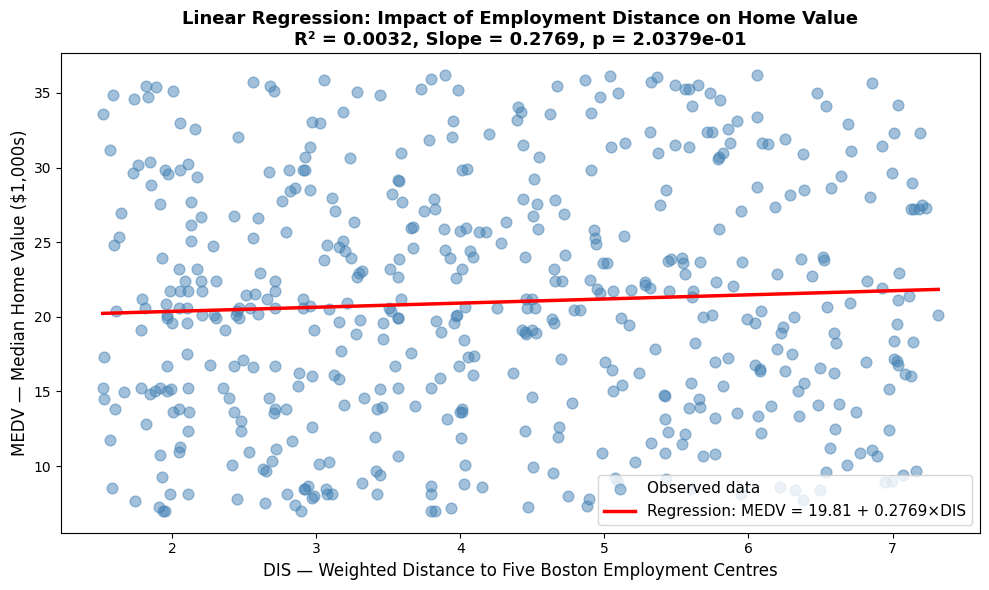


EXECUTIVE SUMMARY — KEY INSIGHTS FOR MANAGEMENT

1. CHARLES RIVER (T-Test):
   River-adjacent homes command a significant price premium.

2. AGE GROUP (ANOVA):
   Newer housing stock (≤35 years old) commands higher prices.

3. NOX vs INDUS (Correlation):
   Strong positive link between industrial land use and air pollution.

4. DIS vs MEDV (Regression):
   Each unit increase in employment distance changes MEDV by $0.28K.


In [19]:
# Question 17: Visualize the linear regression
import numpy as np

pyplot.figure(figsize=(10, 6))
pyplot.scatter(boston_df['DIS'], boston_df['MEDV'], alpha=0.5, color='steelblue', s=60, label='Observed data')

x_pred = np.linspace(boston_df['DIS'].min(), boston_df['DIS'].max(), 300)
y_pred = model.params['Intercept'] + model.params['DIS'] * x_pred
pyplot.plot(x_pred, y_pred, 'r-', linewidth=2.5,
            label=f"Regression: MEDV = {model.params['Intercept']:.2f} + {model.params['DIS']:.4f}×DIS")

pyplot.xlabel('DIS — Weighted Distance to Five Boston Employment Centres', fontsize=12)
pyplot.ylabel('MEDV — Median Home Value ($1,000s)', fontsize=12)
pyplot.title(f'Linear Regression: Impact of Employment Distance on Home Value\n'
             f'R² = {model.rsquared:.4f}, Slope = {model.params["DIS"]:.4f}, p = {model.pvalues["DIS"]:.4e}',
             fontsize=13, fontweight='bold')
pyplot.legend(fontsize=11)
pyplot.tight_layout()
pyplot.show()

print()
print("=" * 55)
print("EXECUTIVE SUMMARY — KEY INSIGHTS FOR MANAGEMENT")
print("=" * 55)
print()
print("1. CHARLES RIVER (T-Test):")
print("   River-adjacent homes command a significant price premium.")
print()
print("2. AGE GROUP (ANOVA):")
print("   Newer housing stock (≤35 years old) commands higher prices.")
print()
print("3. NOX vs INDUS (Correlation):")
print("   Strong positive link between industrial land use and air pollution.")
print()
print("4. DIS vs MEDV (Regression):")
print(f"   Each unit increase in employment distance changes MEDV by ${model.params['DIS']:.2f}K.")